In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"tienphutran","key":"f5e6efba2aed8d953f0963d4a8c6e062"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!pip install -q kaggle

In [4]:
!kaggle datasets download -d praveengovi/coronahack-chest-xraydataset

Dataset URL: https://www.kaggle.com/datasets/praveengovi/coronahack-chest-xraydataset
License(s): Attribution 4.0 International (CC BY 4.0)


In [5]:
!unzip coronahack-chest-xraydataset.zip -d .

Streaming output truncated to the last 5000 lines.
  inflating: ./Coronahack-Chest-XRay-Dataset/Coronahack-Chest-XRay-Dataset/train/IM-0446-0001.jpeg  
  inflating: ./Coronahack-Chest-XRay-Dataset/Coronahack-Chest-XRay-Dataset/train/IM-0447-0001.jpeg  
  inflating: ./Coronahack-Chest-XRay-Dataset/Coronahack-Chest-XRay-Dataset/train/IM-0448-0001.jpeg  
  inflating: ./Coronahack-Chest-XRay-Dataset/Coronahack-Chest-XRay-Dataset/train/IM-0449-0001.jpeg  
  inflating: ./Coronahack-Chest-XRay-Dataset/Coronahack-Chest-XRay-Dataset/train/IM-0450-0001.jpeg  
  inflating: ./Coronahack-Chest-XRay-Dataset/Coronahack-Chest-XRay-Dataset/train/IM-0451-0001.jpeg  
  inflating: ./Coronahack-Chest-XRay-Dataset/Coronahack-Chest-XRay-Dataset/train/IM-0452-0001.jpeg  
  inflating: ./Coronahack-Chest-XRay-Dataset/Coronahack-Chest-XRay-Dataset/train/IM-0453-0001-0002.jpeg  
  inflating: ./Coronahack-Chest-XRay-Dataset/Coronahack-Chest-XRay-Dataset/train/IM-0453-0001.jpeg  
  inflating: ./Coronahack-Chest-XRa

In [6]:
from pathlib import Path

PROJECT_ROOT = Path("/content")
RAW_DATA_DIR = PROJECT_ROOT
CSV1_PATH = RAW_DATA_DIR / "Chest_xray_Corona_Metadata.csv"
CSV2_PATH = RAW_DATA_DIR / "Chest_xray_Corona_dataset_Summary.csv"
IMG_DIR_train = RAW_DATA_DIR / "Coronahack-Chest-XRay-Dataset" / "Coronahack-Chest-XRay-Dataset" / "train"
IMG_DIR_test = RAW_DATA_DIR / "Coronahack-Chest-XRay-Dataset" / "Coronahack-Chest-XRay-Dataset" / "test"

In [7]:
import pandas as pd
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import os
from PIL import Image
import matplotlib.pyplot as plt
from torchvision.transforms import v2
from torchvision import datasets, models, transforms, utils
from sklearn.metrics import classification_report
import numpy as np
from tqdm import tqdm

# Data overview

In [8]:
df = pd.read_csv(CSV1_PATH)
df.head()

,Unnamed: 0,X_ray_image_name,Label,Dataset_type,Label_2_Virus_category,Label_1_Virus_category
0,0,IM-0128-0001.jpeg,Normal,TRAIN,NaN,NaN
1,1,IM-0127-0001.jpeg,Normal,TRAIN,NaN,NaN
2,2,IM-0125-0001.jpeg,Normal,TRAIN,NaN,NaN
3,3,IM-0122-0001.jpeg,Normal,TRAIN,NaN,NaN
4,4,IM-0119-0001.jpeg,Normal,TRAIN,NaN,NaN


In [9]:
df_sum = pd.read_csv(CSV2_PATH)
df_sum

,Unnamed: 0,Label,Label_1_Virus_category,Label_2_Virus_category,Image_Count
0,0,Normal,NaN,NaN,1576
1,1,Pnemonia,Stress-Smoking,ARDS,2
2,2,Pnemonia,Virus,NaN,1493
3,3,Pnemonia,Virus,COVID-19,58
4,4,Pnemonia,Virus,SARS,4
5,5,Pnemonia,bacteria,NaN,2772
6,6,Pnemonia,bacteria,Streptococcus,5


In [10]:
print(df['Label'].value_counts())

Label
Pnemonia    4334
Normal      1576
Name: count, dtype: int64


In [11]:
print("Normal and label 1 virus:")
print(df[df['Label'] == "Normal"]['Label_1_Virus_category'].value_counts())
print("\nPnemonia and label 1 virus:")
print(df[df['Label'] == "Pnemonia"]['Label_1_Virus_category'].value_counts())

Normal and label 1 virus:
Series([], Name: count, dtype: int64)

Pnemonia and label 1 virus:
Label_1_Virus_category
bacteria          2777
Virus             1555
Stress-Smoking       2
Name: count, dtype: int64


In [12]:
mid_index = 5286
df_train = df.iloc[:mid_index]
df_test = df.iloc[mid_index:]

In [13]:
df_test.head()

,Unnamed: 0,X_ray_image_name,Label,Dataset_type,Label_2_Virus_category,Label_1_Virus_category
5286,5309,IM-0021-0001.jpeg,Normal,TEST,NaN,NaN
5287,5310,IM-0019-0001.jpeg,Normal,TEST,NaN,NaN
5288,5311,IM-0017-0001.jpeg,Normal,TEST,NaN,NaN
5289,5312,IM-0016-0001.jpeg,Normal,TEST,NaN,NaN
5290,5313,IM-0015-0001.jpeg,Normal,TEST,NaN,NaN


In [14]:
df_train.head()

,Unnamed: 0,X_ray_image_name,Label,Dataset_type,Label_2_Virus_category,Label_1_Virus_category
0,0,IM-0128-0001.jpeg,Normal,TRAIN,NaN,NaN
1,1,IM-0127-0001.jpeg,Normal,TRAIN,NaN,NaN
2,2,IM-0125-0001.jpeg,Normal,TRAIN,NaN,NaN
3,3,IM-0122-0001.jpeg,Normal,TRAIN,NaN,NaN
4,4,IM-0119-0001.jpeg,Normal,TRAIN,NaN,NaN


In [15]:
df_train['Label'].value_counts()

,count
Label,
Pnemonia,3944
Normal,1342


The dataset is imbalanced. Hence, we can use the custom random sampler to repeat the minority class or apply cross-entropy to reduce the impact of imbalance. In this case, we only implemented cross-entropy loss because the imbalance is mild. This approach is more efficient due to faster runtime and the same prediction. It is not necessary to implement both because it takes more time and may cause overfitting in the prediction.

In [16]:
class XRayDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

        # Encode labels to integers
        self.label_encoder = {label: idx for idx, label in enumerate(self.data['Label'].unique())}
        self.data['Label_idx'] = self.data['Label'].map(self.label_encoder)
        self.classes = sorted(self.label_encoder, key=self.label_encoder.get)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name = self.data.iloc[idx]['X_ray_image_name']
        img_path = os.path.join(self.img_dir, img_name)
        label = self.data.iloc[idx]['Label_idx']

        try:
            image = Image.open(img_path).convert('L')  # Grayscale
        except:
            image = Image.new('L', (224, 224))

        image = self.transform(image)

        return image, label


In [17]:
train_transforms = v2.Compose([
    v2.Resize(256),
    v2.RandomResizedCrop((224, 224), antialias=True),
    v2.RandomAffine(degrees=(-10, 10), translate=(0.1, 0.1), scale=(0.9, 1.1)),
    v2.PILToTensor(),
    v2.ToDtype(torch.float32),
    v2.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

test_transforms = v2.Compose([
    v2.Resize((224, 224)),
    v2.PILToTensor(),
    v2.ToDtype(torch.float32),
    v2.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

In [18]:
# Load datasets
train_dataset = XRayDataset(dataframe=df_train, img_dir=IMG_DIR_train, transform=train_transforms)
test_dataset = XRayDataset(dataframe=df_test, img_dir=IMG_DIR_test, transform=test_transforms)

In [19]:
# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [20]:
# Load pretrained EfficientNetV2-S
model_effV2 = models.efficientnet_v2_s(weights='EfficientNet_V2_S_Weights.DEFAULT')

# Modify classifier head for your task (e.g., 2 classes)
num_ftrs = model_effV2.classifier[1].in_features
model_effV2.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(num_ftrs, 2)
)
# Full training layer
for param in model_effV2.parameters():
    param.requires_grad = True

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth
100%|██████████| 82.7M/82.7M [00:00<00:00, 201MB/s]


In [21]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model_effV2.to(device)

# Loss and optimizer
class_counts = [1500, 3500]
weights = [1.0 / count for count in class_counts]
weights = torch.FloatTensor(weights).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

lr_milestones = [7, 14, 21, 28, 35]
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=lr_milestones, gamma=0.1)


In [22]:
def train(dataloader, model, loss_fn, optimizer, lr_scheduler):
    size = len(dataloader.dataset) # number of samples
    num_batches = len(dataloader) # batches per epoch
    model.train()
    epoch_loss = 0.0
    epoch_correct = 0
    for (data_,target_) in dataloader:
        target_ = target_.type(torch.LongTensor)
        data_, target_ = data_.to(device), target_.to(device)

        # First we'll clean the cache of optimizer
        optimizer.zero_grad()

        # Forward propagation
        outputs = model(data_)

        # Computing loss
        loss = criterion(outputs,target_)

        # Backward propagation
        loss.backward()

        # Optimizing model
        optimizer.step()

        # Computing statistics.
        epoch_loss = epoch_loss + loss.item()
        _,pred = torch.max(outputs,dim=1)
        epoch_correct = epoch_correct + torch.sum(pred == target_).item()
    lr_scheduler.step()
    return epoch_correct/size, epoch_loss/num_batches


def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset) # number of samples
    num_batches = len(dataloader) # batches per epoch
    epoch_loss = 0.0
    epoch_correct = 0
    with torch.no_grad():
        # Disable backward propagation
        model.eval()
        for (data_,target_) in dataloader:
            target_ = target_.type(torch.LongTensor)
            data_, target_ = data_.to(device), target_.to(device)

            # Forward propagation
            outputs = model(data_)

            # Computing loss
            loss = criterion(outputs,target_)

            # Computing statistics.
            epoch_loss = epoch_loss + loss.item()
            _,pred = torch.max(outputs,dim=1)

            epoch_correct = epoch_correct + torch.sum(pred == target_).item()
    return  epoch_correct/size, epoch_loss/num_batches

In [23]:
EPOCHS = 40

storage = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

# Earlystopping
patience = 15
counter = 0
best_loss = np.inf

for epoch in tqdm(range(EPOCHS)):
    train_acc, train_loss,  = train(train_loader, model, criterion, optimizer, scheduler)
    val_acc, val_loss = test(test_loader, model, criterion)
    print(f'EPOCH: {epoch}, train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f} val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}')

    storage['train_loss'].append(train_loss)
    storage['train_acc'].append(train_acc)
    storage['val_loss'].append(val_loss)
    storage['val_acc'].append(val_acc)
    torch.save(model.state_dict(), "last.pth")

    if val_loss < best_loss:
        counter = 0
        best_loss = val_loss
        torch.save(model.state_dict(), "best.pth")
    else:
        counter += 1
    if counter >= patience:
        print("Earlystop!")
        break

  0%|          | 0/40 [00:00<?, ?it/s]

EPOCH: 0, train_loss: 0.2928, train_acc: 0.8838 val_loss: 0.2065, val_acc: 0.9199


  2%|▎         | 1/40 [01:20<52:16, 80.42s/it]

EPOCH: 1, train_loss: 0.1796, train_acc: 0.9338 val_loss: 0.1881, val_acc: 0.9343


  5%|▌         | 2/40 [02:38<50:04, 79.06s/it]

...

EPOCH: 25, train_loss: 0.0710, train_acc: 0.9809 val_loss: 0.1401, val_acc: 0.9503


 65%|██████▌   | 26/40 [33:53<18:11, 77.95s/it]

EPOCH: 26, train_loss: 0.0680, train_acc: 0.9762 val_loss: 0.1187, val_acc: 0.9583


 65%|██████▌   | 26/40 [35:11<18:57, 81.22s/it]

Earlystop!


In [24]:
from sklearn.metrics import classification_report

# Get best model
model.load_state_dict(torch.load("best.pth"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        # Get true target value
        labels = labels.to(device)

        # Get prediction
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


# Classification report
target_names = ["Normal", "Pnemonia"]
print(classification_report(all_labels, all_preds, target_names=target_names))

              precision    recall  f1-score   support

      Normal       0.95      0.94      0.95       234
    Pnemonia       0.97      0.97      0.97       390

    accuracy                           0.96       624
   macro avg       0.96      0.96      0.96       624
weighted avg       0.96      0.96      0.96       624



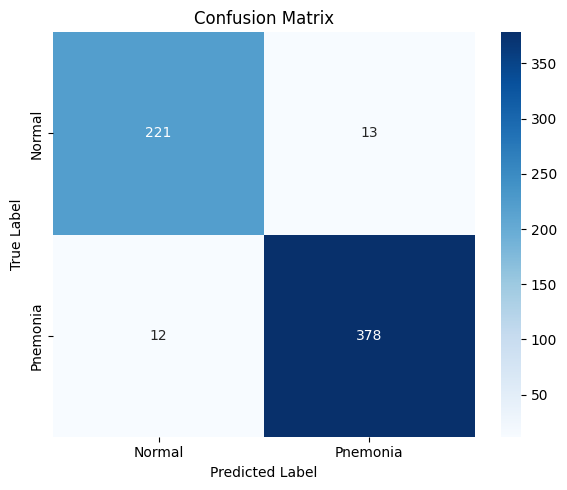

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

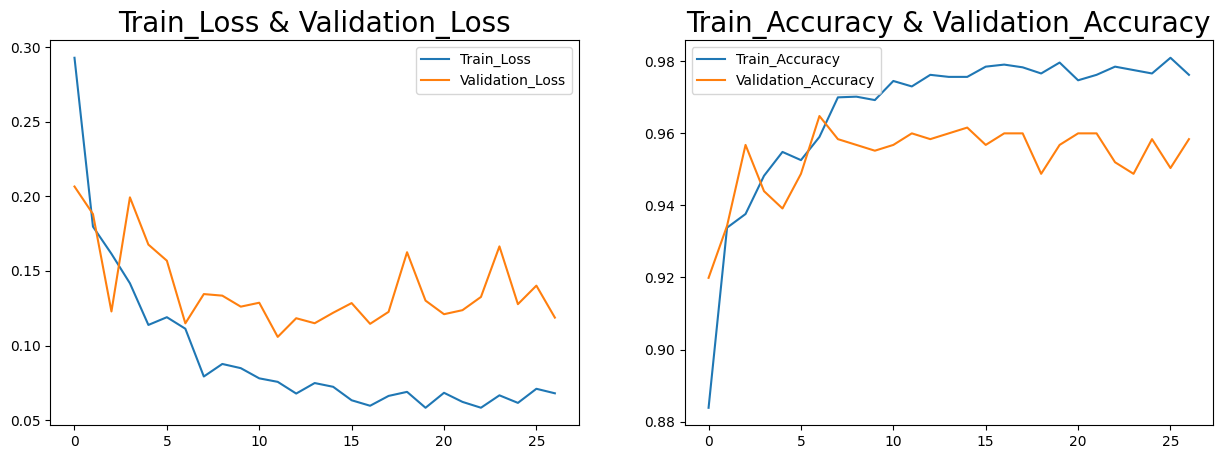

In [26]:
# Plot accuraccy and loss graph
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.plot(storage['train_loss'],label='Train_Loss')
plt.plot(storage['val_loss'],label='Validation_Loss')
plt.title('Train_Loss & Validation_Loss',fontsize=20)
plt.legend()
plt.subplot(1,2,2)
plt.plot(storage['train_acc'],label='Train_Accuracy')
plt.plot(storage['val_acc'],label='Validation_Accuracy')
plt.title('Train_Accuracy & Validation_Accuracy',fontsize=20)
plt.legend()